In [1]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2
import globals
import parse_data.prepare_data as prepare_data
import data_extraction.trial_list_filters as trial_list_filters
from matplotlib.patches import Wedge
from matplotlib import pyplot as plt
import data_extraction.get_indices as get_indices
import parse_data.identify_filepaths as identify_filepaths
import globals
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.patches import Polygon
from matplotlib import cm
import math
from parse_data import flip_rotate_trajectories
# import occupancy_and_strategy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import data_strings
import data_extraction.data_saving as data_saving
import plotting.plot_octagon as plot_octagon
import analysis.heatmap_phigh as heatmap_phigh
import pickle
import os

In [3]:
data_folder = '/Volumes/ogma/human_octagon/RAW/risky'

In [4]:
json_filenames_social, json_filenames_solo = identify_filepaths.get_filenames(data_folder)

In [6]:
_, trial_lists_social = prepare_data.prepare_data(data_folder, json_filenames_social, combine=False)
_, trial_lists_solo = prepare_data.prepare_data(data_folder, json_filenames_solo, combine=False)

IntProgress(value=0, max=30)

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-56-08_RH27_TF27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-00-17_KB27_VB27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-30-32_VS21_AW21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-25-04_UD21_MM21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_1/2025-07-28_09-26-02_CM28_AH28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_2/2025-07-28_10-28-37_AO28_RF28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250801_1/2025-08-01_11-24-29_IL01_TJ01_Social.json
Loading complete.
Preprocessing complete.
filepath: /Vo

IntProgress(value=0, max=120)

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-51_RH27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-39_RH27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-33_TF27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-18_TF27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-29_KB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-20-57_KB27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-13_VB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/

In [9]:
# trial type: "RiskyChoice"

In [10]:
def probability_choose_high_social(data_folder, json_filename, trial_type=globals.HIGH_LOW, wall_sep=None):

    # get the dataframe for this session
    df, trial_list = prepare_data.prepare_data(data_folder, json_filename)

    # filter trial list to include HighLow trials only
    if trial_type is not None:
        trial_list_indices = get_indices.get_trials_trialtype(trial_list, trial_type=trial_type)
        trial_list = [trial_list[i] for i in trial_list_indices]
    # print(f"len trial list = {len(trial_list)}")

    # filter trial list to include specific wall separation
    if wall_sep is not None:
        trial_list_indices =  get_indices.get_trials_with_wall_sep(trial_list, wall_sep=wall_sep)
        trial_list = [trial_list[i] for i in trial_list_indices]

    # find the high wall trials and the indices where each player won
    high_wall_chosen = get_indices.was_high_wall_chosen(trial_list)
    # print(f"high_wall_chosen = {high_wall_chosen}")
    player0_win_indices = get_indices.get_player_win_indices(trial_list, player_id=0)
    # print(f"player0_win_indices = {player0_win_indices}")
    player1_win_indices = get_indices.get_player_win_indices(trial_list, player_id=1)
    # print(f"player1_win_indices = {player1_win_indices}")

    # create an array of size player_win_indices that is True where this win was a High wall choice 
    player0_wins_high = np.zeros(player0_win_indices.size)
    for i in range(player0_win_indices.size):
        trial_idx = player0_win_indices[i]
        player0_wins_high[i] = True if high_wall_chosen[trial_idx] else False

    player1_wins_high = np.zeros(player1_win_indices.size)
    for i in range(player1_win_indices.size):
        trial_idx = player1_win_indices[i]
        player1_wins_high[i] = True if high_wall_chosen[trial_idx] else False

    probability_player0_choose_high = player0_wins_high[player0_wins_high == True].size/player0_wins_high.size
    probability_player1_choose_high = player1_wins_high[player1_wins_high == True].size/player1_wins_high.size

    return probability_player0_choose_high, probability_player1_choose_high

In [13]:
def probability_choose_high_solo(data_folder, json_filename, trial_type=globals.HIGH_LOW, wall_sep=None):

    # get the dataframe for this session
    df, trial_list = prepare_data.prepare_data(data_folder, json_filename)

    # filter trial list to include HighLow trials only
    if trial_type is not None:
        trial_list_indices = get_indices.get_trials_trialtype(trial_list, trial_type=trial_type)
        trial_list = [trial_list[i] for i in trial_list_indices]


    # filter trial list to include specific wall separation
    if wall_sep is not None:
        trial_list_indices =  get_indices.get_trials_with_wall_sep(trial_list, wall_sep=wall_sep)
        trial_list = [trial_list[i] for i in trial_list_indices]

    high_wall_chosen = get_indices.was_high_wall_chosen(trial_list)

    probability_choose_high = high_wall_chosen[high_wall_chosen == True].size/trial_list_indices.size


    return probability_choose_high

In [21]:
json_filenames_first_solo = []
json_filenames_second_solo = []
for i in range(0, len(json_filenames_solo), 2):
    json_filenames_first_solo.append(json_filenames_solo[i])
    json_filenames_second_solo.append(json_filenames_solo[i+1])

In [30]:
# assign to pseudonyms

import parse_data.identify_filepaths as identify_filepaths

data_folder = '/Volumes/ogma/human_octagon/RAW/risky'

social_files, ordered_solos = identify_filepaths.get_filenames(data_folder=data_folder)

import re

pseudo_tuples_list = []
experiment_dates_socials = []
for file in social_files:
     # match the session number and the pseudonym string
    match = re.search(r'(\d+_\d)[/\\](\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})_(.*?_.*?)_Social\.json', file)
    if not match:
        print(f"Filename does not match expected pattern: {file}")
    if match:
        session, date, time, pseudonyms = match.groups()
        pseudo_tuples = pseudonyms.split('_')[0::]
        pseudo_tuples_list.append(pseudo_tuples)
        experiment_dates_socials.append((date, pseudo_tuples))

In [31]:
pseudo_tuples_list

[['RH27', 'TF27'],
 ['KB27', 'VB27'],
 ['VS21', 'AW21'],
 ['UD21', 'MM21'],
 ['CM28', 'AH28'],
 ['AO28', 'RF28'],
 ['IL01', 'TJ01'],
 ['XG04', 'YC04'],
 ['PC04', 'NC04'],
 ['SD19', 'EL19'],
 ['MB20', 'PM20'],
 ['DK20', 'LZ20'],
 ['YW21', 'DK21'],
 ['BC21', 'ES21'],
 ['XT28', 'YL28'],
 ['CG28', 'DB28'],
 ['YW30', 'AS30'],
 ['AP30', 'CM30'],
 ['SG31', 'SM31'],
 ['JN07', 'AK07'],
 ['LZ11', 'AA11'],
 ['CM11', 'HM11'],
 ['RW14', 'AA14'],
 ['JY14', 'SZ14'],
 ['SG14', 'FN14'],
 ['NM17', 'VO17'],
 ['WG17', 'FK17'],
 ['KL18', 'ZZ18'],
 ['KC18', 'NG18'],
 ['NC18', 'GK18']]

In [23]:
first_solo_p_risky = {}
for i, json_filename in enumerate(json_filenames_first_solo):
    first_solo_p_risky[i] = {}
    probability_choose_risky = probability_choose_high_solo(data_folder, json_filename, trial_type="RiskyChoice")
    first_solo_p_risky[i]=probability_choose_risky

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-51_RH27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-33_TF27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-29_KB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-13_VB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-19-06_VS21_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-18-52_AW21_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-12-05_UD21_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/hum

In [85]:
first_solo_p_high = {}
for i, json_filename in enumerate(json_filenames_first_solo):
    first_solo_p_risky[i] = {}
    probability_choose_risky = probability_choose_high_solo(data_folder, json_filename, trial_type="HighLow")
    first_solo_p_risky[i]=probability_choose_risky

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-51_RH27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-33_TF27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-29_KB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-13_VB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-19-06_VS21_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-18-52_AW21_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-12-05_UD21_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/hum

In [51]:
p_risky_dict = {
    'social': {},
    'first_solo': {},
    'second_solo': {},
}

In [52]:
solo_pseudos_arr = np.array(pseudo_tuples_list).ravel()
solo_pseudos = [str(x) for x in solo_pseudos_arr]

In [12]:
social_p_risky = {}
for i, json_filename in enumerate(json_filenames_social):
    social_p_risky[i] = {}
    probability_player0_choose_risky, probability_player1_choose_risky = probability_choose_high_social(data_folder, json_filename, trial_type="RiskyChoice")
    social_p_risky[i][0]=probability_player0_choose_risky
    social_p_risky[i][1]=probability_player1_choose_risky

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-56-08_RH27_TF27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-00-17_KB27_VB27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-30-32_VS21_AW21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-25-04_UD21_MM21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_1/2025-07-28_09-26-02_CM28_AH28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_2/2025-07-28_10-28-37_AO28_RF28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250801_1/2025-08-01_11-24-29_IL01_TJ01_Social.json
Loading complete.
Preprocessing complete.
filepath: /Vo

In [86]:
social_p_risky = {}
for i, json_filename in enumerate(json_filenames_social):
    social_p_risky[i] = {}
    probability_player0_choose_risky, probability_player1_choose_risky = probability_choose_high_social(data_folder, json_filename, trial_type="HighLow")
    social_p_risky[i][0]=probability_player0_choose_risky
    social_p_risky[i][1]=probability_player1_choose_risky

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-56-08_RH27_TF27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-00-17_KB27_VB27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-30-32_VS21_AW21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-25-04_UD21_MM21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_1/2025-07-28_09-26-02_CM28_AH28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_2/2025-07-28_10-28-37_AO28_RF28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250801_1/2025-08-01_11-24-29_IL01_TJ01_Social.json
Loading complete.
Preprocessing complete.
filepath: /Vo

In [54]:
for i, tuple in enumerate(pseudo_tuples_list):
    player0 = tuple[0]
    player1 = tuple[1]

    p_risky_dict['social'][player0] = social_p_risky[i][0]
    p_risky_dict['social'][player1] = social_p_risky[i][1]

In [24]:
second_solo_p_risky = {}
for i, json_filename in enumerate(json_filenames_second_solo):
    second_solo_p_risky[i] = {}
    probability_choose_risky = probability_choose_high_solo(data_folder, json_filename, trial_type="RiskyChoice")
    second_solo_p_risky[i]=probability_choose_risky

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-39_RH27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-18_TF27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-20-57_KB27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-21-07_VB27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-52-10_VS21_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-52-33_AW21_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-51-11_UD21_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/o

In [55]:
for i, pseudo in enumerate(solo_pseudos):
    
    p_risky_dict['first_solo'][pseudo] = first_solo_p_risky[i]
    p_risky_dict['second_solo'][pseudo] = second_solo_p_risky[i]

In [58]:
import matplotlib.pyplot as plt

In [84]:
import pickle
with open('p_risky.pkl', 'wb') as fp:
    pickle.dump(p_risky_dict, fp)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_76380/681052736.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Spectral').copy()


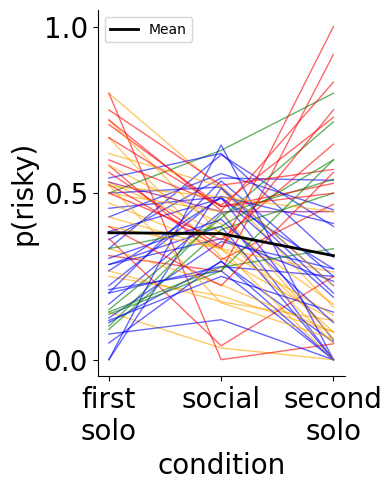

In [89]:
conditions = ['first_solo', 'social', 'second_solo']
labels = ['first solo', 'social', 'second solo']

participants = p_risky_dict['first_solo'].keys()

plt.figure(figsize=(4, 5))
cmap = cm.get_cmap('Spectral').copy()

for i, pseudonym in enumerate(participants):

    color = cmap(i / (len(participants) - 1))
    
    y = [p_risky_dict[cond][pseudonym] for cond in conditions]
    social = p_risky_dict['social'][pseudonym]
    first_solo = p_risky_dict['first_solo'][pseudonym]
    second_solo = p_risky_dict['second_solo'][pseudonym]

    if first_solo < social and social > second_solo:
        plt.plot(
            conditions,
            y,
            color='b',
            alpha=0.6,
            linewidth=1
        )
    elif first_solo > social and social < second_solo:
            plt.plot(
            conditions,
            y,
            color='r',
            alpha=0.6,
            linewidth=1
        )
    elif first_solo < social and social < second_solo:
            plt.plot(
            conditions,
            y,
            color='g',
            alpha=0.6,
            linewidth=1
        )
    elif first_solo > social and social > second_solo:
            plt.plot(
            conditions,
            y,
            color='orange',
            alpha=0.6,
            linewidth=1
        )
    else:
            plt.plot(
            conditions,
            y,
            color='purple',
            alpha=0.6,
            linewidth=1
        )
means = [
    np.mean(list(p_risky_dict[cond].values()))
    for cond in conditions
]

plt.plot(
    conditions,
    means,
    linewidth=2,
    color='k',
    label='Mean'
)

plt.legend()

plt.ylabel('p(risky)', fontsize=20)
plt.xlabel('condition', fontsize=20)

ax = plt.gca()
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=20)

plt.yticks(np.arange(0,1.1,0.5))
plt.xticks(
    ticks=[0, 1, 2],
    labels=['first\nsolo','social','second\nsolo',])

plt.tight_layout()
plt.show()